In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [41]:
output_png = r"output"

In [42]:
# โหลดจาก CSV ที่ export ไว้
df = pd.read_csv(r"dataset\Olist_Delivered.csv")
df


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_prep_item,day_delivery,...,payment_type,max_installments,total_value,review_score,day_comment,product_category_name_english,freight_ratio,month_purchase,year_purchase,d_cal
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,credit_card,1.0,18.12,4.0,1.0,housewares,0.290764,10,2017,2017_10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,voucher,1.0,20.59,4.0,1.0,housewares,0.290764,10,2017,2017_10
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2.0,12.0,...,boleto,1.0,141.46,4.0,0.0,perfumery,0.191744,7,2018,2018_07
3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.0,9.0,...,credit_card,3.0,179.12,5.0,4.0,auto,0.120200,8,2018,2018_08
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,4.0,10.0,...,credit_card,1.0,72.20,5.0,2.0,pet_shop,0.604444,11,2017,2017_11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102467,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1.0,7.0,...,credit_card,3.0,85.08,5.0,1.0,health_beauty,0.181667,3,2017,2017_03
102468,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0,21.0,...,credit_card,3.0,195.00,4.0,1.0,baby,0.114923,2,2018,2018_02
102469,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1.0,24.0,...,credit_card,5.0,271.01,5.0,0.0,home_appliances_2,0.315646,8,2017,2017_08
102470,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,4.0,13.0,...,credit_card,4.0,441.16,2.0,1.0,computers_accessories,0.225513,1,2018,2018_01


In [43]:
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_prep_item,day_delivery,...,payment_type,max_installments,total_value,review_score,day_comment,product_category_name_english,freight_ratio,month_purchase,year_purchase,d_cal
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,credit_card,1.0,18.12,4.0,1.0,housewares,0.290764,10,2017,2017_10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,6.0,...,voucher,1.0,20.59,4.0,1.0,housewares,0.290764,10,2017,2017_10
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2.0,12.0,...,boleto,1.0,141.46,4.0,0.0,perfumery,0.191744,7,2018,2018_07


In [44]:
df["days_to_approve"] = (df["order_approved_at"].dt.normalize() - df["order_purchase_timestamp"].dt.normalize()).dt.days
df["days_to_carrier"] = (df["order_delivered_carrier_date"].dt.normalize() - df["order_approved_at"].dt.normalize()).dt.days
df["DAYWEEK_purch"] = df["order_purchase_timestamp"].dt.dayofweek
df["price_per_item"] = df["total_price"]/df["count_items"]
df["is_low_score"] = df["review_score"]<=2.0
df.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_prep_item,day_delivery,...,product_category_name_english,freight_ratio,month_purchase,year_purchase,d_cal,days_to_approve,days_to_carrier,DAYWEEK_purch,price_per_item,is_low_score
56856,076ae5516316ecf9f17dc3cc78437eac,b4f336ced5b1329e0220ff0dbe7d30d9,delivered,2018-02-15 19:28:04,2018-02-15 19:46:15,2018-02-17 00:10:31,2018-03-02 23:58:53,2018-03-13,2.0,13.0,...,auto,0.601792,2,2018,2018_02,0.0,2.0,3,27.90,False
61365,fdc9d53919c301a0d27f2aad205c5aea,c72574999d02567190f02835c3af476a,delivered,2017-11-26 01:02:57,2017-11-26 01:10:56,2017-11-29 15:06:55,2017-12-14 19:35:11,2017-12-18,3.0,15.0,...,sports_leisure,0.212658,11,2017,2017_11,0.0,3.0,6,79.00,False
63674,ba97c57ecadaf7dafa0a372f38210d0c,0b23254194f2cb64d9fba926fc891d83,delivered,2017-07-05 20:07:33,2017-07-05 20:23:17,2017-07-06 12:56:46,2017-07-07 19:15:21,2017-07-18,1.0,1.0,...,garden_tools,0.193756,7,2017,2017_07,0.0,1.0,2,60.54,True
99050,5db44e5b8064f2de158539b19c8e3ad8,13a6fed7991b5ea1ea707705457e60e3,delivered,2017-07-14 23:36:32,2017-07-14 23:45:07,2017-07-19 20:36:44,2017-07-24 21:59:37,2017-08-03,5.0,5.0,...,bed_bath_table,0.424731,7,2017,2017_07,0.0,5.0,4,27.90,False
86472,1f7db95b8fd2c7432d59242430cb2163,e046f992a304cc92e1b00d7fccdf1c42,delivered,2018-02-08 10:33:28,2018-02-08 10:50:22,2018-02-08 22:32:28,2018-03-08 12:36:34,2018-03-13,0.0,28.0,...,computers_accessories,0.300143,2,2018,2018_02,0.0,0.0,3,69.90,False
74420,d43c0241a5f6a832183448eb8dbe18e6,ae9fe453e6f022b89b6b4c2427a0250c,delivered,2018-03-05 11:18:50,2018-03-06 04:20:25,2018-03-08 02:05:37,2018-03-19 18:02:47,2018-03-28,3.0,11.0,...,health_beauty,0.192376,3,2018,2018_03,1.0,2.0,0,84.99,False
63718,0f4a2c067346862463f78a1ca0e4e43b,65ea7f5e0134c0596d687b04eb47d33c,delivered,2018-02-27 20:03:29,2018-02-27 20:15:36,2018-02-28 20:43:39,2018-04-09 17:38:52,2018-03-23,1.0,40.0,...,health_beauty,0.105333,2,2018,2018_02,0.0,1.0,1,150.00,True
70719,af6e44b9d409160a33f41a80537af9b2,1a71c3ead49ef67aed93c31aacc4d046,delivered,2017-10-03 14:30:50,2017-10-04 02:49:34,2017-10-04 18:48:09,2017-10-18 16:40:28,2017-11-09,1.0,14.0,...,auto,0.518352,10,2017,2017_10,1.0,0.0,1,91.00,False
71602,fc2893781987c8064e5db53f1ce4ec3f,213793bce063883455855e97246b1b0b,delivered,2018-04-07 08:33:36,2018-04-07 08:47:54,2018-04-09 20:48:39,2018-04-11 13:58:21,2018-04-19,2.0,2.0,...,electronics,0.552667,4,2018,2018_04,0.0,2.0,5,15.00,False
37614,7cb79316d2abe37e16ec83a07afb2895,f5025a3893cbcdd251b06c0b3f7451da,delivered,2018-03-22 18:08:10,2018-03-22 18:15:31,2018-03-23 18:57:24,2018-05-01 18:41:32,2018-04-13,1.0,39.0,...,NaN,0.531487,3,2018,2018_03,0.0,1.0,3,34.30,True


In [45]:
feature_cols = [
    # delivery features
    'actual_delivery_days',
    'estimated_delivery_days',
    'is_late',
    'days_to_approve',
    'days_to_carrier',

    # price features
    'total_price',
    'total_freight',
    'freight_ratio',
    'price_per_item',
    'count_items',
    'max_installments',

    # time features
    'month_purchase',
    'DAYWEEK_purch',
]

# df[feature_cols]

# # categorical ที่ต้อง encode
cat_cols = ['payment_type', 'product_category_name_english']


In [46]:
df_encoded = pd.get_dummies(
    df[feature_cols + cat_cols + ['is_low_score']],
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

df_encoded

,actual_delivery_days,estimated_delivery_days,is_late,days_to_approve,days_to_carrier,total_price,total_freight,freight_ratio,price_per_item,count_items,...,product_category_name_english_security_and_services,product_category_name_english_signaling_and_security,product_category_name_english_small_appliances,product_category_name_english_small_appliances_home_oven_and_coffee,product_category_name_english_sports_leisure,product_category_name_english_stationery,product_category_name_english_tablets_printing_image,product_category_name_english_telephony,product_category_name_english_toys,product_category_name_english_watches_gifts
0,8.0,16,0,0.0,2.0,29.99,8.72,0.290764,29.99,1,...,0,0,0,0,0,0,0,0,0,0
1,8.0,16,0,0.0,2.0,29.99,8.72,0.290764,29.99,1,...,0,0,0,0,0,0,0,0,0,0
2,14.0,20,0,2.0,0.0,118.70,22.76,0.191744,118.70,1,...,0,0,0,0,0,0,0,0,0,0
3,9.0,27,0,0.0,0.0,159.90,19.22,0.120200,159.90,1,...,0,0,0,0,0,0,0,0,0,0
4,14.0,27,0,0.0,4.0,45.00,27.20,0.604444,45.00,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102467,8.0,19,0,0.0,1.0,72.00,13.08,0.181667,72.00,1,...,0,0,0,0,0,0,0,0,0,0
102468,22.0,24,0,0.0,1.0,174.90,20.10,0.114923,174.90,1,...,0,0,0,0,0,0,0,0,0,0
102469,25.0,31,0,0.0,1.0,205.99,65.02,0.315646,205.99,1,...,0,0,0,0,0,0,0,0,0,0
102470,17.0,38,0,0.0,4.0,359.98,81.18,0.225513,179.99,2,...,0,0,0,0,0,0,0,0,0,0


In [47]:
# ── Handle Missing Values ────────────────────────────
print("Missing ก่อน fillna:")
print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])

Missing ก่อน fillna:
actual_delivery_days     8
days_to_approve         14
days_to_carrier         16
max_installments         1
dtype: int64


In [48]:
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col] = df_encoded[col].fillna(
            df_encoded[col].median()
        )

In [49]:
core_features = [
    'actual_delivery_days', 'estimated_delivery_days',
    'is_late', 'days_to_approve', 'days_to_carrier',
    'total_price', 'freight_ratio', 'price_per_item',
    'count_items', 'month_purchase', 'is_low_score'
]

corr_matrix = df_encoded[core_features].corr()
corr_matrix


,actual_delivery_days,estimated_delivery_days,is_late,days_to_approve,days_to_carrier,total_price,freight_ratio,price_per_item,count_items,month_purchase,is_low_score
actual_delivery_days,1.000000,0.380742,0.587883,0.080054,0.379939,0.058970,0.074404,0.061883,-0.020305,-0.056990,0.287600
estimated_delivery_days,0.380742,1.000000,-0.061249,0.036881,0.199201,0.071860,0.117120,0.070399,0.020520,-0.093845,0.043923
is_late,0.587883,-0.061249,1.000000,0.029413,0.208297,0.018653,0.007269,0.022976,-0.017582,-0.024084,0.340929
days_to_approve,0.080054,0.036881,0.029413,1.000000,-0.078289,0.014823,0.034499,0.004874,0.026246,0.009980,0.009867
days_to_carrier,0.379939,0.199201,0.208297,-0.078289,1.000000,0.073184,-0.020127,0.067892,0.024232,0.016680,0.131153
total_price,0.058970,0.071860,0.018653,0.014823,0.073184,1.000000,-0.286685,0.941767,0.095295,0.001358,0.025362
freight_ratio,0.074404,0.117120,0.007269,0.034499,-0.020127,-0.286685,1.000000,-0.297362,0.075563,-0.011189,0.019976
price_per_item,0.061883,0.070399,0.022976,0.004874,0.067892,0.941767,-0.297362,1.000000,-0.081193,0.000365,0.003048
count_items,-0.020305,0.020520,-0.017582,0.026246,0.024232,0.095295,0.075563,-0.081193,1.000000,0.004304,0.125565
month_purchase,-0.056990,-0.093845,-0.024084,0.009980,0.016680,0.001358,-0.011189,0.000365,0.004304,1.000000,-0.023218


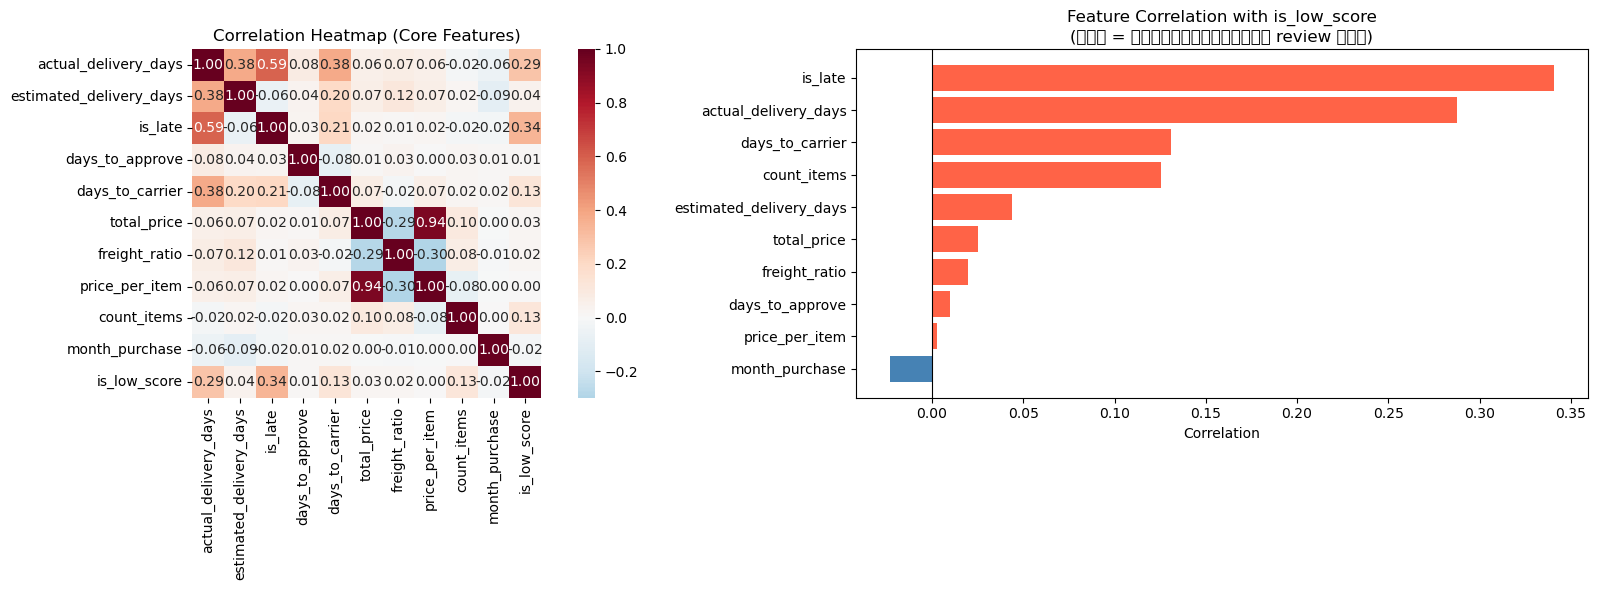

Top features ที่สัมพันธ์กับ is_low_score:
is_late                    0.340929
actual_delivery_days       0.287600
days_to_carrier            0.131153
count_items                0.125565
estimated_delivery_days    0.043923
Name: is_low_score, dtype: float64


In [50]:
# ── Full Heatmap ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # แสดงตัวเลขใน cell
    fmt='.2f',           # format ทศนิยม 2 ตำแหน่ง
    cmap='RdBu_r',       # แดง=ลบ, น้ำเงิน=บวก
    center=0,            # กึ่งกลางที่ 0
    square=True,
    ax=axes[0]
)
axes[0].set_title('Correlation Heatmap (Core Features)', fontsize=12)

# ── Bar chart: correlation กับ target ───────────────
target_corr = (
    corr_matrix['is_low_score']
    .drop('is_low_score')    # ตัด self-correlation ออก
    .sort_values()
)

colors = ['tomato' if x > 0 else 'steelblue' for x in target_corr]
# แดง = สัมพันธ์บวก (feature สูง → score ต่ำ)
# น้ำเงิน = สัมพันธ์ลบ (feature สูง → score สูง)

axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with is_low_score\n'
                   '(แดง = ยิ่งสูงยิ่งได้ review ต่ำ)', fontsize=12)
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.savefig(output_png + "correlation_heatmap.png", dpi=150)
plt.show()

# ── สรุป top features ────────────────────────────────
print("Top features ที่สัมพันธ์กับ is_low_score:")
print(target_corr.abs().sort_values(ascending=False).head(5))

In [51]:
# ═══════════════════════════════════════════════════
# CELL 5 : Export
# ═══════════════════════════════════════════════════

df_encoded.to_csv(r'dataset\ml_ready.csv', index=False)

print(f"✅ ml_ready.csv exported")
print(f"   Shape  : {df_encoded.shape}")
print(f"   Target : low_score_mean")
print(f"   Class distribution:")
print(f"   {df_encoded['is_low_score'].value_counts().to_dict()}")
print(f"\n🎉 Notebook 2 Complete! พร้อมไป Notebook 3 — ML Model")

✅ ml_ready.csv exported
   Shape  : (102472, 87)
   Target : low_score_mean
   Class distribution:
   {False: 88661, True: 13811}

🎉 Notebook 2 Complete! พร้อมไป Notebook 3 — ML Model
